To systematically assess whether the latent space effectively preserves chemical similarities, we sampled 1 000 000 random molecule pairs from the test set and computed the Tanimoto similarity between their Morgan fingerprints and the Euclidean distance between their embeddings.

This was done with:
    python scripts/compute_distances.py ${PATH_TO_TEST_SET}
                                        --nb_pairs 1000000
                                        --random_seed 42
                                        --output_file results/pubchem_small_organic/test_1000000_pairs_seed_42.csv

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats as st

MAIN_DIR = Path('../../')
res_dir = MAIN_DIR/'results'/'pubchem_small_organic'

df = pd.read_csv(res_dir/'test_1000000_pairs_seed_42.csv')

In [2]:
df

,smiles1,smiles2,tanimoto_similarity,euclidean_distance
0,CCCC1CCC(C#N)C(S(=O)(=O)C2CCCC(C)C2)C1,CC(N(CCC#N)CCC#N)N(CCC#N)CCC#N,0.096154,17.677319
1,O=C(O)C1CCN(S(=O)(=O)N2CCCC2)C1,CC(=O)NC1=NC(C(=O)NC2=CC(F)=C(N3CC(C)OC(C)C3)C...,0.114286,17.063448
2,CC1=CN=C(C2=NC(C3CC3)=CC(Cl)=N2)C=C1,CC1=C(CC(=O)N2CCC3=C2C=CC(N)=C3F)C2=CC=CC=C2N1,0.092105,16.872379
3,COC1=CC=CC=C1C(=O)NC1=C(N2CCCN(CC3=CC(C(F)(F)F...,CC1=NN(C)C(Cl)=C1CC(N)CC1OCCO1,0.086022,18.902346
4,CC1=C(C(=O)NNC(=O)C2=CC=CO2)OC2=C1/C(=N\O)CC(C...,CN(CC(=O)NC(C)(C)C)C(=O)CSC1=NNC(C2CC2)=N1,0.093023,14.741940
...,...,...,...,...
999995,O=C(NC1=CC=CC=C1OCC(F)(F)F)C1=CC=C(S(=O)(=O)N2...,O=C(CSC1=NN=CC2=CC=CC=C12)NC1=C(Cl)C=CC([N+](=...,0.170455,13.394794
999996,OC1=C(N=NC2=C(O)C=C(Br)C=C2)C=CC(Br)=C1,CC(C)CNC1=NC2=CC=CC=C2N2C(C3=CC=C(C(=O)NCC(N)=...,0.054795,18.746523
999997,CC(C1=CC2=C(C=C1)N=CC=C2)N1N=NC2=CC=C(C3=CNN=C...,CC1=NC(NC(=O)C2CCCN(C(=O)C3CC3)C2)=NN1,0.095238,18.649494
999998,CC(N)C1=NC=CN1C1CCCC1,COCCN(CC(=O)NC1=CC=CC2=C1N=CC=C2)C(C)=O,0.088235,18.245029


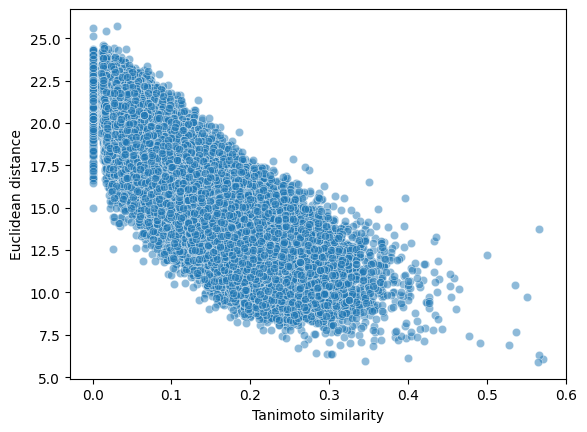

In [3]:
plt.figure()
sns.scatterplot(x=df['tanimoto_similarity'], y=df['euclidean_distance'], alpha=0.5)
plt.xlabel('Tanimoto similarity')
plt.ylabel('Euclidean distance')
plt.show()

In [4]:
st.pearsonr(df['tanimoto_similarity'], df['euclidean_distance'])

PearsonRResult(statistic=np.float64(-0.8401201396914668), pvalue=np.float64(0.0))